In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load preprocesed splits
X_train_resampled = pd.read_csv("Data/X_train_resampled.csv")
y_train_resampled = pd.read_csv("Data/y_train_resampled.csv").squeeze()
X_val_scaled = pd.read_csv("Data/X_val_scaled.csv")
y_val = pd.read_csv("Data/y_val.csv").squeeze()
X_test_scaled = pd.read_csv("Data/X_test_scaled.csv")
y_test = pd.read_csv("Data/y_test.csv").squeeze()

print("Loaded preprocessed splits.")
print(f"  SMOTE'd train: {X_train_resampled.shape[0]:,} samples")
print(f"  Validation:    {X_val_scaled.shape[0]:,} samples")
print(f"  Test:          {X_test_scaled.shape[0]:,} samples")

Loaded preprocessed splits.
  SMOTE'd train: 288,488 samples
  Validation:    34,467 samples
  Test:          34,468 samples


In [3]:
# Random Forest: Training & Tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)

print("Starting Random Forest grid search...")
rf_grid.fit(X_train_resampled, y_train_resampled)

print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV AUC-ROC: {rf_grid.best_score_:.4f}")

Starting Random Forest grid search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC-ROC: 0.9822


In [4]:
# Validation Set Evaluation
rf_best = rf_grid.best_estimator_

rf_val_preds = rf_best.predict(X_val_scaled)
rf_val_probs = rf_best.predict_proba(X_val_scaled)[:, 1]

print("Random Forest: Validation Set Results \n")
print(classification_report(y_val, rf_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, rf_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, rf_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, rf_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, rf_val_preds):.4f}")

Random Forest: Validation Set Results 

               precision    recall  f1-score   support

        No HD       0.93      0.93      0.93     30910
Heart Disease       0.37      0.37      0.37      3557

     accuracy                           0.87     34467
    macro avg       0.65      0.65      0.65     34467
 weighted avg       0.87      0.87      0.87     34467

AUC-ROC:   0.8256
F1:        0.3717
Precision: 0.3740
Recall:    0.3694


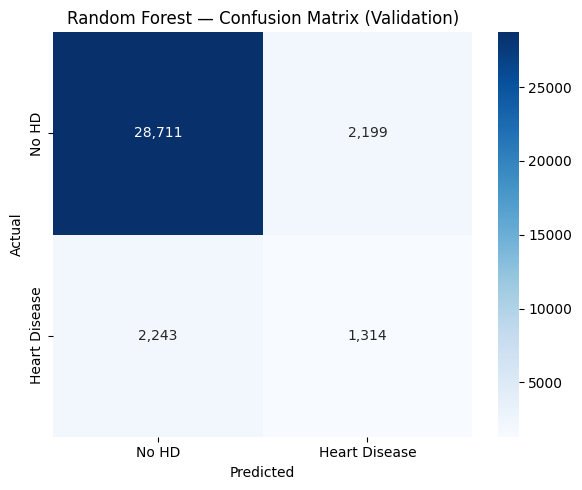

In [5]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_val, rf_val_preds)
sns.heatmap(cm_rf, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()

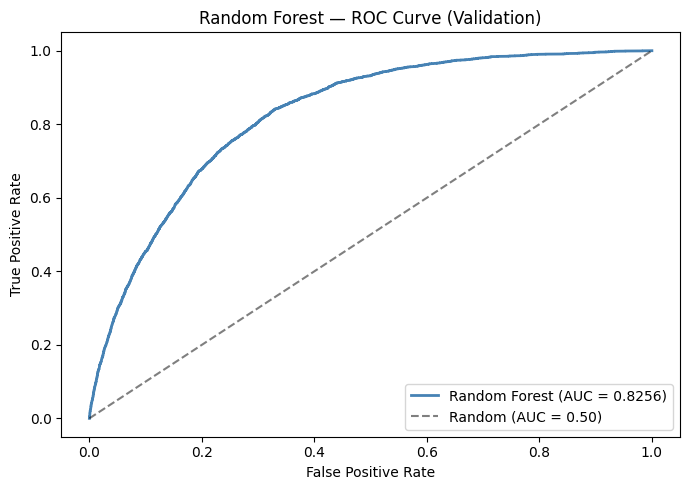

In [6]:
# ROC curve
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_val_probs)
rf_auc = roc_auc_score(y_val, rf_val_probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rf_fpr, rf_tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest — ROC Curve (Validation)')
ax.legend()
plt.tight_layout()
plt.show()

Random Forest: Threshold Optimization 
  Default threshold: 0.50
  Optimal threshold (F2): 0.1691
  Precision at optimal: 0.2275
  Recall at optimal:    0.8395
  F2 at optimal:       0.5458


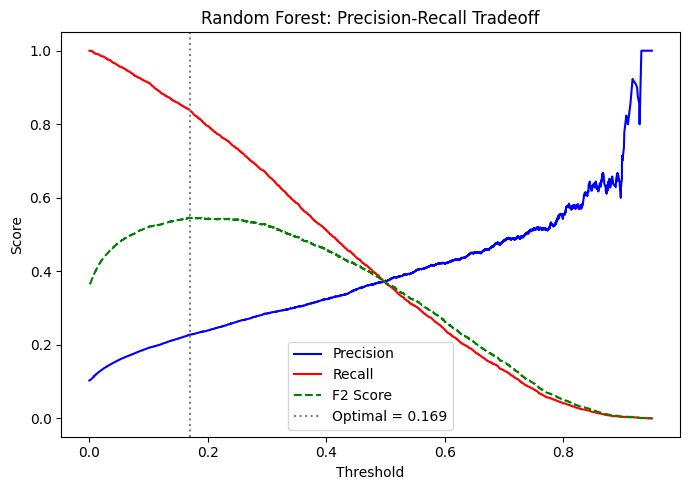

In [7]:
# Threshold Optimization
def find_optimal_threshold(y_true, y_probs, model_name, beta=2.0):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    fbeta_scores = ((1 + beta**2) * precisions * recalls) / (beta**2 * precisions + recalls + 1e-8)
    best_idx = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_idx]

    print(f"{model_name}: Threshold Optimization ")
    print(f"  Default threshold: 0.50")
    print(f"  Optimal threshold (F{beta:.0f}): {best_threshold:.4f}")
    print(f"  Precision at optimal: {precisions[best_idx]:.4f}")
    print(f"  Recall at optimal:    {recalls[best_idx]:.4f}")
    print(f"  F{beta:.0f} at optimal:       {fbeta_scores[best_idx]:.4f}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(thresholds, precisions[:-1], 'b-', label='Precision')
    ax.plot(thresholds, recalls[:-1], 'r-', label='Recall')
    ax.plot(thresholds, fbeta_scores[:-1], 'g--', label=f'F{beta:.0f} Score')
    ax.axvline(x=best_threshold, color='gray', linestyle=':', label=f'Optimal = {best_threshold:.3f}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name}: Precision-Recall Tradeoff')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return best_threshold

rf_threshold = find_optimal_threshold(y_val, rf_val_probs, "Random Forest")

In [8]:
# Re-evaluate at optimal threshold
rf_opt_preds = (rf_val_probs >= rf_threshold).astype(int)

print(f"\nRandom Forest: Results at threshold {rf_threshold:.4f}\n")
print(classification_report(y_val, rf_opt_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, rf_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, rf_opt_preds):.4f}")
print(f"Precision: {precision_score(y_val, rf_opt_preds):.4f}")
print(f"Recall:    {recall_score(y_val, rf_opt_preds):.4f}")


Random Forest: Results at threshold 0.1691

               precision    recall  f1-score   support

        No HD       0.97      0.67      0.80     30910
Heart Disease       0.23      0.84      0.36      3557

     accuracy                           0.69     34467
    macro avg       0.60      0.76      0.58     34467
 weighted avg       0.90      0.69      0.75     34467

AUC-ROC:   0.8256
F1:        0.3580
Precision: 0.2275
Recall:    0.8395


Random Forest: SHAP Summary


/var/folders/dq/d73590ld0qdgbx2nj4pms7hw0000gn/T/ipykernel_84657/3197765790.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_shap_vals, X_val_scaled.iloc[rf_sample_idx], show=True)
/Users/jonathanwong/anaconda3/envs/heart-health/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/Users/jonathanwong/anaconda3/envs/heart-health/lib/python3.11/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` expl

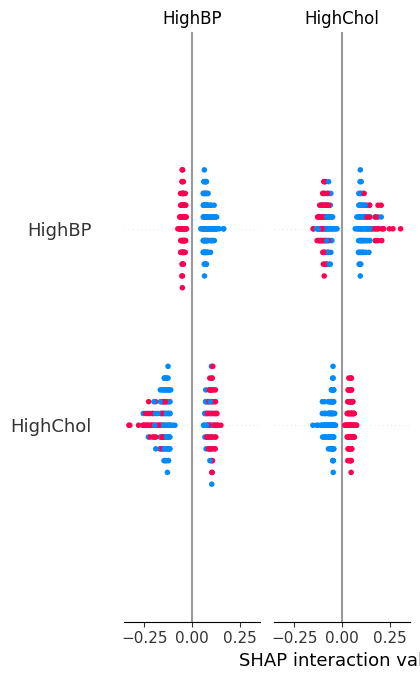

In [9]:
# SHAP Analysis
import shap

rf_sample_idx = np.random.choice(len(X_val_scaled), size=200, replace=False)
rf_explainer = shap.TreeExplainer(rf_best)
rf_shap_values = rf_explainer.shap_values(X_val_scaled.iloc[rf_sample_idx])

if isinstance(rf_shap_values, list):
    rf_shap_vals = rf_shap_values[1]
else:
    rf_shap_vals = rf_shap_values

print("Random Forest: SHAP Summary")
shap.summary_plot(rf_shap_vals, X_val_scaled.iloc[rf_sample_idx], show=True)

Random Forest: SHAP Feature Importance


/var/folders/dq/d73590ld0qdgbx2nj4pms7hw0000gn/T/ipykernel_84657/1167403886.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(rf_shap_vals, X_val_scaled.iloc[rf_sample_idx], plot_type="bar", show=True)
/Users/jonathanwong/anaconda3/envs/heart-health/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/Users/jonathanwong/anaconda3/envs/heart-health/lib/python3.11/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG.

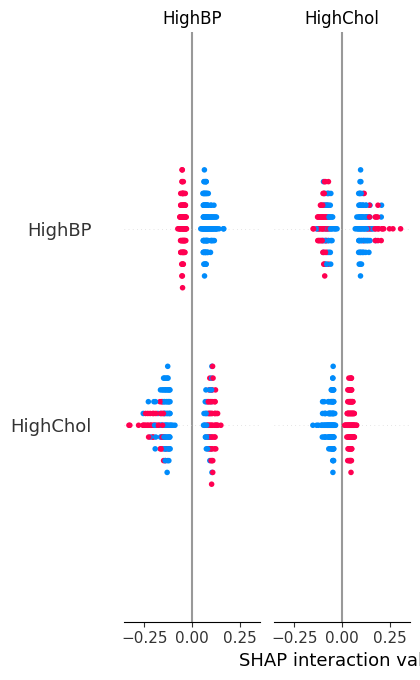

In [10]:
print("Random Forest: SHAP Feature Importance")
shap.summary_plot(rf_shap_vals, X_val_scaled.iloc[rf_sample_idx], plot_type="bar", show=True)

In [11]:
# LIME Analysis
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns.tolist(),
    class_names=['No HD', 'Heart Disease'],
    mode='classification'
)

# Find interesting cases
rf_opt_preds_arr = (rf_val_probs >= rf_threshold).astype(int)
tp_idx = np.where((rf_opt_preds_arr == 1) & (y_val.values == 1))[0]
fn_idx = np.where((rf_opt_preds_arr == 0) & (y_val.values == 1))[0]
print(f"True positives:  {len(tp_idx)}")
print(f"False negatives: {len(fn_idx)}")

True positives:  2986
False negatives: 571


LIME: True Positive
Actual: Heart Disease | Predicted prob: 0.3624


/Users/jonathanwong/anaconda3/envs/heart-health/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


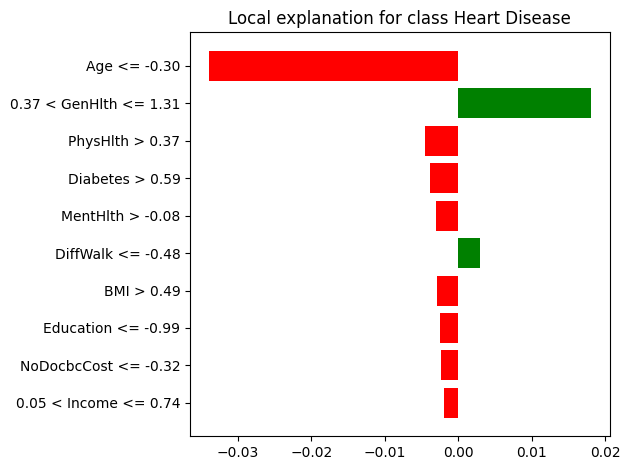

In [12]:
# LIME for a true positive
if len(tp_idx) > 0:
    case_tp = tp_idx[0]
    exp_tp = lime_explainer.explain_instance(
        X_val_scaled.iloc[case_tp].values,
        rf_best.predict_proba, num_features=10
    )
    print("LIME: True Positive")
    print(f"Actual: Heart Disease | Predicted prob: {rf_val_probs[case_tp]:.4f}")
    exp_tp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

LIME: False Negative
Actual: Heart Disease | Predicted prob: 0.0900


/Users/jonathanwong/anaconda3/envs/heart-health/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


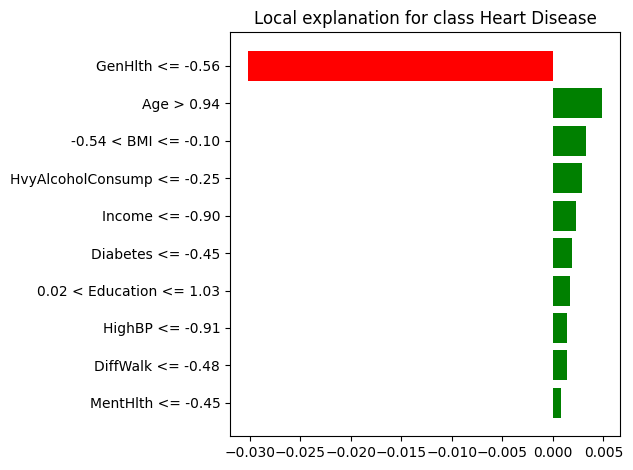

In [13]:
# LIME for a false negative
if len(fn_idx) > 0:
    case_fn = fn_idx[0]
    exp_fn = lime_explainer.explain_instance(
        X_val_scaled.iloc[case_fn].values,
        rf_best.predict_proba, num_features=10
    )
    print("LIME: False Negative")
    print(f"Actual: Heart Disease | Predicted prob: {rf_val_probs[case_fn]:.4f}")
    exp_fn.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

In [14]:
# Test Set Evaluation
rf_test_probs = rf_best.predict_proba(X_test_scaled)[:, 1]
rf_test_preds = (rf_test_probs >= rf_threshold).astype(int)

print(f"Random Forest: Test Set (threshold = {rf_threshold:.4f})\n")
print(classification_report(y_test, rf_test_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_test, rf_test_probs):.4f}")
print(f"F1:        {f1_score(y_test, rf_test_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, rf_test_preds):.4f}")

Random Forest: Test Set (threshold = 0.1691)

               precision    recall  f1-score   support

        No HD       0.97      0.67      0.79     30910
Heart Disease       0.23      0.84      0.36      3558

     accuracy                           0.69     34468
    macro avg       0.60      0.75      0.58     34468
 weighted avg       0.90      0.69      0.75     34468

AUC-ROC:   0.8272
F1:        0.3567
Precision: 0.2268
Recall:    0.8356


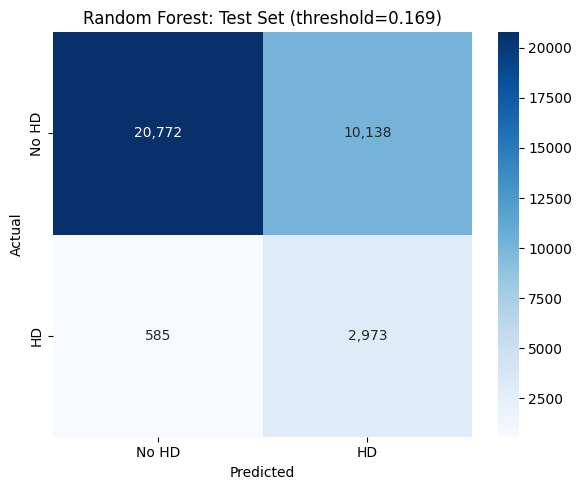

In [15]:
# Test set confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, rf_test_preds), annot=True, fmt=',', cmap='Blues',
            ax=ax, xticklabels=['No HD', 'HD'], yticklabels=['No HD', 'HD'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Random Forest: Test Set (threshold={rf_threshold:.3f})')
plt.tight_layout()
plt.show()

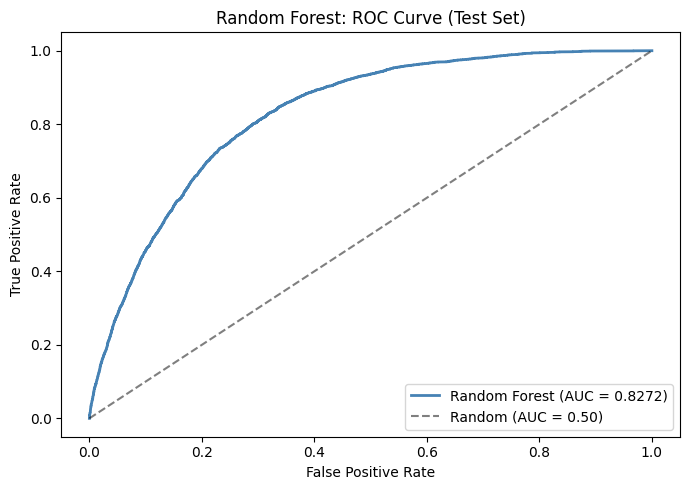

In [16]:
# Test set ROC curve
rf_test_fpr, rf_test_tpr, _ = roc_curve(y_test, rf_test_probs)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rf_test_fpr, rf_test_tpr, color='steelblue', lw=2,
        label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_test_probs):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest: ROC Curve (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()